# Fraud Detection using BiGAN and AnoGAN

Detect fraudulent credit card transactions using two GAN-based anomaly detection approaches:

| Model | Description |
|-------|-------------|
| **AnoGAN** | Anomaly score via latent-space optimisation at inference time |
| **BiGAN** | Anomaly score via encoder-based reconstruction — single forward pass |

Both models are trained **exclusively on normal transactions**.  
Fraudulent transactions produce higher anomaly scores because the generator never learned to reconstruct them.


## 1. Imports & Configuration

In [21]:
# ── Standard library ──────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

# ── Scientific stack ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Scikit-learn ──────────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.manifold import TSNE
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    precision_recall_curve, roc_curve, confusion_matrix,
    classification_report,
)

# ── PyTorch ───────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset


In [22]:
# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ── Hardware ──────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ── Dataset ───────────────────────────────────────────────────────────────────
DATA_PATH = "/kaggle/input/datasets/mayankmishra11029/jghjsghjgshkj/creditcard.csv"

# ── Architecture hyperparameters ──────────────────────────────────────────────
LATENT_DIM  = 32
INPUT_DIM   = None  # set after loading data

# ── Training hyperparameters ──────────────────────────────────────────────────
BATCH_SIZE      = 512
NUM_EPOCHS_ANO  = 200   # AnoGAN epochs
NUM_EPOCHS_BI   = 200   # BiGAN epochs
LR              = 1e-4
LABEL_SMOOTH    = 0.9   # soft real labels (1.0 → 0.9) to prevent D over-confidence
N_CRITIC_G      = 2     # G updates per D step (counters discriminator dominance)
N_CRITIC_GE     = 2     # G+E updates per D step
LAMBDA_RECON    = 1.0   # cycle-consistency MSE weight in BiGAN G+E loss

# ── Inference ─────────────────────────────────────────────────────────────────
SCORE_BATCH_SIZE = 1024  # batch size for anomaly score computation


Using device: cuda


## 2. Data Loading & Preprocessing

In [23]:
df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape}")
print(f"\nClass distribution:\n{df['Class'].value_counts()}")
print(f"\nFraud ratio: {df['Class'].mean() * 100:.3f}%")
df.head()


Dataset shape: (284807, 31)

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud ratio: 0.173%


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [24]:
def preprocess_features(df: pd.DataFrame):
    """
    Extract labels and features.
    - Amount is log1p-transformed to reduce right-skew.
    - log1p is applied before any split (no leakage: it is a row-wise,
      parameter-free transformation).
    Returns
    -------
    labels        : np.ndarray, shape (N,)
    features_raw  : np.ndarray, shape (N, D)
    feature_cols  : list[str]
    """
    labels = df['Class'].values
    features = df.drop(columns=['Class']).copy()
    features['Amount'] = np.log1p(features['Amount'])
    return labels, features.values, features.columns.tolist()


labels, features_raw, feature_cols = preprocess_features(df)
INPUT_DIM = features_raw.shape[1]

normal_features_raw = features_raw[labels == 0]
fraud_features_raw  = features_raw[labels == 1]

print(f"Input dimension : {INPUT_DIM}")
print(f"Feature columns : {feature_cols}")
print(f"\nNormal samples  : {len(normal_features_raw):,}")
print(f"Fraud samples   : {len(fraud_features_raw):,}")
print("\nStandardScaler will be fit on training normals ONLY (next cell) to avoid data leakage.")


Input dimension : 30
Feature columns : ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']

Normal samples  : 284,315
Fraud samples   : 492

StandardScaler will be fit on training normals ONLY (next cell) to avoid data leakage.


In [25]:
def build_splits(normal_raw, fraud_raw, seed=SEED):
    """
    Create a leakage-free train / val / test split.

    Procedure
    ---------
    1. Split normals 80 / 20 (train / held-out) before fitting the scaler.
    2. Fit StandardScaler on training normals only.
    3. Combine held-out normals + all fraud into an evaluation pool.
    4. Split the evaluation pool 50 / 50 stratified → val (threshold tuning)
       and test (final reported metrics).

    Returns
    -------
    X_train_normal : scaled training normals
    X_eval         : scaled evaluation pool (normals + fraud)
    y_eval         : binary labels for evaluation pool
    val_idx        : indices into X_eval / y_eval for the val partition
    test_idx       : indices into X_eval / y_eval for the test partition
    scaler         : fitted StandardScaler
    """
    X_train_raw, X_holdout_raw = train_test_split(
        normal_raw, test_size=0.2, random_state=seed
    )

    scaler = StandardScaler()
    X_train   = scaler.fit_transform(X_train_raw)
    X_holdout = scaler.transform(X_holdout_raw)
    X_fraud   = scaler.transform(fraud_raw)

    X_eval = np.concatenate([X_holdout, X_fraud], axis=0)
    y_eval = np.concatenate(
        [np.zeros(len(X_holdout)), np.ones(len(X_fraud))], axis=0
    )

    splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=seed)
    val_idx, test_idx = next(splitter.split(X_eval, y_eval))

    return X_train, X_eval, y_eval, val_idx, test_idx, scaler


X_train_normal, X_eval, y_eval, val_idx, test_idx, scaler = build_splits(
    normal_features_raw, fraud_features_raw
)

print(f"Scaler fit on   : {X_train_normal.shape[0]:,} training normals only")
print(f"Train set       : {X_train_normal.shape}")
print(f"Val set         : {len(val_idx):,} samples  (fraud ratio: {y_eval[val_idx].mean()*100:.3f}%)")
print(f"Test set        : {len(test_idx):,} samples  (fraud ratio: {y_eval[test_idx].mean()*100:.3f}%)")


Scaler fit on   : 227,452 training normals only
Train set       : (227452, 30)
Val set         : 28,677 samples  (fraud ratio: 0.858%)
Test set        : 28,678 samples  (fraud ratio: 0.858%)


In [26]:
# Build PyTorch DataLoader for training and a GPU-resident evaluation tensor
train_dataset = TensorDataset(torch.FloatTensor(X_train_normal))
train_loader  = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True
)

eval_tensor = torch.FloatTensor(X_eval).to(device)

y_val  = y_eval[val_idx]
y_test = y_eval[test_idx]


## 3. AnoGAN

**Idea:** Train a standard GAN (Generator + Discriminator) on normal transactions only.  
At inference time, for each sample we optimise a latent vector `z` so that `G(z)` reconstructs the input.

**Anomaly score** = λ · Residual + (1-λ) · Discrimination, with λ = 0.1  
- *Residual loss*: `||x − G(z*)||₁` — how well the generator reconstructs the sample  
- *Discrimination loss*: `||f(x) − f(G(z*))||₁` — discrepancy in discriminator feature space  

Fraudulent samples are harder to reconstruct → higher anomaly scores.


### 3.1 Model Architecture

In [27]:
class AnoGAN_Generator(nn.Module):
    """Maps latent vector z → data space."""

    def __init__(self, latent_dim: int, output_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 64),  nn.BatchNorm1d(64),  nn.LeakyReLU(0.2),
            nn.Linear(64, 128),         nn.BatchNorm1d(128), nn.LeakyReLU(0.2),
            nn.Linear(128, 256),        nn.BatchNorm1d(256), nn.LeakyReLU(0.2),
            nn.Linear(256, output_dim),
        )

    def forward(self, z):
        return self.net(z)


class AnoGAN_Discriminator(nn.Module):
    """
    Spectral-normalised discriminator.
    Enforces the Lipschitz constraint to prevent D from dominating training.
    Exposes intermediate features for the AnoGAN discrimination loss.
    """

    def __init__(self, input_dim: int):
        super().__init__()
        SN = nn.utils.spectral_norm
        self.feature_extractor = nn.Sequential(
            SN(nn.Linear(input_dim, 256)), nn.LeakyReLU(0.2), nn.Dropout(0.3),
            SN(nn.Linear(256, 128)),       nn.LeakyReLU(0.2), nn.Dropout(0.3),
            SN(nn.Linear(128, 64)),        nn.LeakyReLU(0.2),
        )
        self.classifier = nn.Sequential(
            SN(nn.Linear(64, 1)),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.classifier(self.feature_extractor(x))

    def get_features(self, x):
        return self.feature_extractor(x)


ano_G = AnoGAN_Generator(LATENT_DIM, INPUT_DIM).to(device)
ano_D = AnoGAN_Discriminator(INPUT_DIM).to(device)
print(ano_G)
print(ano_D)


AnoGAN_Generator(
  (net): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2)
    (3): Linear(in_features=64, out_features=128, bias=True)
    (4): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.2)
    (6): Linear(in_features=128, out_features=256, bias=True)
    (7): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): LeakyReLU(negative_slope=0.2)
    (9): Linear(in_features=256, out_features=30, bias=True)
  )
)
AnoGAN_Discriminator(
  (feature_extractor): Sequential(
    (0): Linear(in_features=30, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Dropout(p=0.3, inpl

 ### 3.2 Training 

In [29]:
def train_anogan(generator, discriminator, loader, num_epochs,
                 lr=LR, label_smooth=LABEL_SMOOTH, n_critic_g=N_CRITIC_G):
    """
    Train an AnoGAN (Generator + Discriminator) on normal data.

    - Discriminator is updated once per batch with soft real labels.
    - Generator is updated `n_critic_g` times per batch to counter D dominance.

    Returns
    -------
    g_losses, d_losses : per-epoch average losses
    """
    criterion = nn.BCELoss()
    opt_G = optim.Adam(generator.parameters(),     lr=lr, betas=(0.5, 0.999))
    opt_D = optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))

    g_losses, d_losses = [], []

    for epoch in range(num_epochs):
        epoch_g, epoch_d, n_batches = 0.0, 0.0, 0

        for (real_data,) in loader:
            real_data  = real_data.to(device)
            batch_size = real_data.size(0)
            real_labels = torch.full((batch_size, 1), label_smooth, device=device)
            fake_labels = torch.zeros(batch_size, 1, device=device)

            # ── Discriminator step ────────────────────────────────────────────
            z        = torch.randn(batch_size, LATENT_DIM, device=device)
            fake_data = generator(z).detach()
            d_loss = criterion(discriminator(real_data), real_labels) +                      criterion(discriminator(fake_data), fake_labels)
            opt_D.zero_grad(); d_loss.backward(); opt_D.step()

            # ── Generator step (n_critic_g updates) ──────────────────────────
            g_accum = 0.0
            for _ in range(n_critic_g):
                z         = torch.randn(batch_size, LATENT_DIM, device=device)
                fake_data = generator(z)
                g_loss    = criterion(
                    discriminator(fake_data),
                    torch.ones(batch_size, 1, device=device)
                )
                opt_G.zero_grad(); g_loss.backward(); opt_G.step()
                g_accum += g_loss.item()

            epoch_g += g_accum / n_critic_g
            epoch_d += d_loss.item()
            n_batches += 1

        g_losses.append(epoch_g / n_batches)
        d_losses.append(epoch_d / n_batches)

        if (epoch + 1) % 25 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}]  "
                  f"D_loss: {d_losses[-1]:.4f}  G_loss: {g_losses[-1]:.4f}")

    return g_losses, d_losses


ano_g_losses, ano_d_losses = train_anogan(ano_G, ano_D, train_loader, NUM_EPOCHS_ANO)


Epoch [25/200]  D_loss: 1.3532  G_loss: 0.8192
Epoch [50/200]  D_loss: 1.3542  G_loss: 0.8184
Epoch [75/200]  D_loss: 1.3541  G_loss: 0.8179
Epoch [100/200]  D_loss: 1.3545  G_loss: 0.8176
Epoch [125/200]  D_loss: 1.3532  G_loss: 0.8182
Epoch [150/200]  D_loss: 1.3555  G_loss: 0.8165
Epoch [175/200]  D_loss: 1.3565  G_loss: 0.8158
Epoch [200/200]  D_loss: 1.3567  G_loss: 0.8161


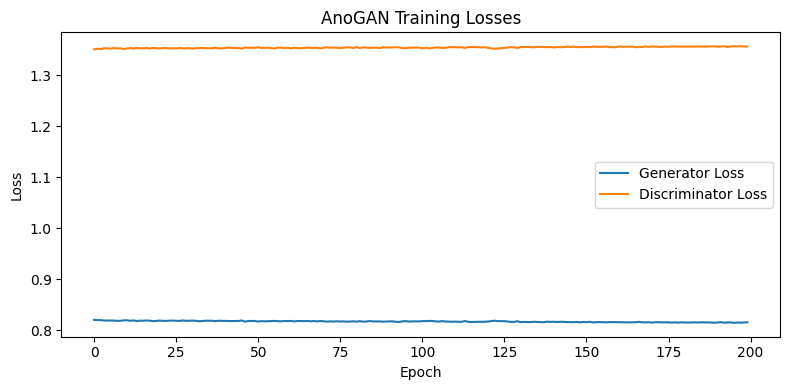

In [30]:
def plot_loss_curves(loss_pairs, title, figsize=(8, 4)):
    """Plot one or more (values, label) loss curves on a single axis."""
    fig, ax = plt.subplots(figsize=figsize)
    for values, label in loss_pairs:
        ax.plot(values, label=label)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.set_title(title); ax.legend()
    plt.tight_layout(); plt.show()


plot_loss_curves(
    [(ano_g_losses, 'Generator Loss'), (ano_d_losses, 'Discriminator Loss')],
    title='AnoGAN Training Losses',
)


### 3.3 Anomaly Scoring

For each test sample **x**, we optimise a latent vector **z** so that G(z) ≈ x.

**Anomaly Score** = λ · Residual + (1−λ) · Discrimination, λ = 0.1

Multiple random initialisations are used; the **minimum** score per sample is kept  
to reduce variance from unlucky starting points.


In [31]:
def anogan_anomaly_score_batch(G, D, x_batch, latent_dim,
                                lambda_val=0.1, n_iter=500,
                                lr=0.01, n_inits=3):
    """
    Compute AnoGAN anomaly scores via z-optimisation with multiple random starts.

    Parameters
    ----------
    G, D       : trained generator and discriminator (eval mode set inside)
    x_batch    : (B, D) tensor on the correct device
    n_inits    : number of random z initialisations per sample
    lambda_val : weight for residual vs discrimination loss

    Returns
    -------
    best_scores : np.ndarray, shape (B,)  — minimum score across initialisations
    """
    G.eval(); D.eval()
    batch_size  = x_batch.size(0)
    best_scores = None

    for _ in range(n_inits):
        z = torch.randn(batch_size, latent_dim, device=x_batch.device, requires_grad=True)
        opt_z = optim.Adam([z], lr=lr)

        # Optimise z to minimise reconstruction + discrimination loss
        for _ in range(n_iter):
            with torch.enable_grad():
                x_rec      = G(z)
                residual   = torch.mean(torch.abs(x_batch - x_rec), dim=1)
                feat_loss  = torch.mean(torch.abs(D.get_features(x_batch) -
                                                   D.get_features(x_rec)), dim=1)
                loss = torch.mean(lambda_val * residual + (1 - lambda_val) * feat_loss)
                opt_z.zero_grad(); loss.backward(); opt_z.step()

        # Final score at converged z
        with torch.no_grad():
            x_rec     = G(z)
            residual  = torch.mean(torch.abs(x_batch - x_rec), dim=1)
            feat_loss = torch.mean(torch.abs(D.get_features(x_batch) -
                                              D.get_features(x_rec)), dim=1)
            scores = lambda_val * residual + (1 - lambda_val) * feat_loss

        best_scores = scores if best_scores is None else torch.minimum(best_scores, scores)

    return best_scores.cpu().numpy()


def compute_scores_batched(score_fn, eval_tensor, batch_size=SCORE_BATCH_SIZE, desc=""):
    """Apply `score_fn(batch)` in chunks and concatenate results."""
    all_scores = []
    total = len(eval_tensor)
    if desc:
        print(f"Computing {desc} scores for {total:,} samples...")

    for i in range(0, total, batch_size):
        batch  = eval_tensor[i : i + batch_size]
        scores = score_fn(batch)
        all_scores.append(scores)
        if desc and (i // batch_size + 1) % 10 == 0:
            print(f"  Processed {min(i + batch_size, total):,} / {total:,}")

    result = np.concatenate(all_scores)
    if desc:
        print(f"Done. Score range: [{result.min():.4f}, {result.max():.4f}]")
    return result


anogan_scores_raw = compute_scores_batched(
    lambda batch: anogan_anomaly_score_batch(ano_G, ano_D, batch, LATENT_DIM),
    eval_tensor,
    desc="AnoGAN (3 inits × 500 z-opt iters per batch)",
)


Computing AnoGAN (3 inits × 500 z-opt iters per batch) scores for 57,355 samples...
  Processed 10,240 / 57,355
  Processed 20,480 / 57,355
  Processed 30,720 / 57,355
  Processed 40,960 / 57,355
  Processed 51,200 / 57,355
Done. Score range: [0.0029, 4.3699]


## 4. BiGAN (Bidirectional GAN)

**Idea:** BiGAN adds an **Encoder** network alongside the Generator.  
The Discriminator operates on *pairs* `(x, z)` — it sees `(x, E(x))` as real  
and `(G(z), z)` as fake.

At inference time, anomaly scoring is a **single forward pass** — no expensive z-optimisation.

**Anomaly score** = α · ||x − G(E(x))||₂ + β · ||f_D(x,z) − f_D(x_rec,z)||₂


### 4.1 Model Architecture

In [37]:
class BiGAN_Generator(nn.Module):
    """Maps latent vector z → data space.  Identical architecture to AnoGAN Generator."""

    def __init__(self, latent_dim: int, output_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 64),  nn.BatchNorm1d(64),  nn.LeakyReLU(0.2),
            nn.Linear(64, 128),         nn.BatchNorm1d(128), nn.LeakyReLU(0.2),
            nn.Linear(128, 256),        nn.BatchNorm1d(256), nn.LeakyReLU(0.2),
            nn.Linear(256, output_dim),
        )

    def forward(self, z):
        return self.net(z)


class BiGAN_Encoder(nn.Module):
    """Maps data space x → latent vector z (inverse of Generator)."""

    def __init__(self, input_dim: int, latent_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.BatchNorm1d(256), nn.LeakyReLU(0.2),
            nn.Linear(256, 128),       nn.BatchNorm1d(128), nn.LeakyReLU(0.2),
            nn.Linear(128, 64),        nn.BatchNorm1d(64),  nn.LeakyReLU(0.2),
            nn.Linear(64, latent_dim),
        )

    def forward(self, x):
        return self.net(x)


class BiGAN_Discriminator(nn.Module):
    """
    Spectral-normalised discriminator over joint (x, z) pairs.
    Exposes intermediate features for the BiGAN anomaly score.
    """

    def __init__(self, input_dim: int, latent_dim: int):
        super().__init__()
        SN = nn.utils.spectral_norm
        self.feature_extractor = nn.Sequential(
            SN(nn.Linear(input_dim + latent_dim, 256)), nn.LeakyReLU(0.2), nn.Dropout(0.3),
            SN(nn.Linear(256, 128)),                    nn.LeakyReLU(0.2), nn.Dropout(0.3),
            SN(nn.Linear(128, 64)),                     nn.LeakyReLU(0.2),
        )
        self.classifier = nn.Sequential(
            SN(nn.Linear(64, 1)),
            nn.Sigmoid(),
        )

    def _concat(self, x, z):
        return torch.cat([x, z], dim=1)

    def forward(self, x, z):
        return self.classifier(self.feature_extractor(self._concat(x, z)))

    def get_features(self, x, z):
        return self.feature_extractor(self._concat(x, z))


bi_G = BiGAN_Generator(LATENT_DIM, INPUT_DIM).to(device)
bi_E = BiGAN_Encoder(INPUT_DIM, LATENT_DIM).to(device)
bi_D = BiGAN_Discriminator(INPUT_DIM, LATENT_DIM).to(device)
print(bi_G); print(bi_E); print(bi_D)


BiGAN_Generator(
  (net): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2)
    (3): Linear(in_features=64, out_features=128, bias=True)
    (4): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.2)
    (6): Linear(in_features=128, out_features=256, bias=True)
    (7): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): LeakyReLU(negative_slope=0.2)
    (9): Linear(in_features=256, out_features=30, bias=True)
  )
)
BiGAN_Encoder(
  (net): Sequential(
    (0): Linear(in_features=30, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): BatchNorm1d(128, eps=1e-05, m

### 4.2 Training

In [38]:
def train_bigan(generator, encoder, discriminator, loader, num_epochs,
                lr=LR, label_smooth=LABEL_SMOOTH,
                n_critic_ge=N_CRITIC_GE, lambda_recon=LAMBDA_RECON):
    """
    Train a BiGAN with optional cycle-consistency reconstruction loss.

    - D is updated once per batch (at half the G+E learning rate).
    - G+E are updated `n_critic_ge` times per batch.
    - A cycle-consistency MSE term (`lambda_recon * MSE(x, G(E(x)))`) is added
      to the G+E adversarial loss when lambda_recon > 0.

    Returns
    -------
    ge_adv_losses, recon_losses, d_losses : per-epoch average losses
    """
    criterion = nn.BCELoss()
    opt_GE = optim.Adam(
        list(generator.parameters()) + list(encoder.parameters()),
        lr=lr, betas=(0.5, 0.999)
    )
    opt_D = optim.Adam(discriminator.parameters(), lr=lr * 0.5, betas=(0.5, 0.999))

    ge_adv_losses, recon_losses, d_losses = [], [], []

    for epoch in range(num_epochs):
        epoch_adv, epoch_recon, epoch_d, n_batches = 0.0, 0.0, 0.0, 0

        for (real_data,) in loader:
            real_data  = real_data.to(device)
            batch_size = real_data.size(0)

            real_smooth = torch.full((batch_size, 1), label_smooth, device=device)
            real_ones   = torch.ones(batch_size,  1, device=device)
            fake_zeros  = torch.zeros(batch_size, 1, device=device)

            # ── Discriminator step ────────────────────────────────────────────
            # Use detached encoder / generator outputs to avoid backprop into G+E
            with torch.no_grad():
                z_enc_d    = encoder(real_data)
                z_prior_d  = torch.randn(batch_size, LATENT_DIM, device=device)
                x_gen_d    = generator(z_prior_d)

            d_loss = (criterion(discriminator(real_data, z_enc_d),   real_smooth) +
                      criterion(discriminator(x_gen_d,  z_prior_d),  fake_zeros))
            opt_D.zero_grad(); d_loss.backward(); opt_D.step()

            # ── G + E step ────────────────────────────────────────────────────
            adv_accum, recon_accum = 0.0, 0.0
            for _ in range(n_critic_ge):
                z_prior = torch.randn(batch_size, LATENT_DIM, device=device)
                z_enc   = encoder(real_data)
                x_gen   = generator(z_prior)
                x_recon = generator(z_enc)   # cycle-consistency reconstruction

                adv_loss   = (criterion(discriminator(real_data, z_enc),  fake_zeros) +
                              criterion(discriminator(x_gen, z_prior),     real_ones))
                recon_loss = torch.mean((real_data - x_recon) ** 2)
                ge_loss    = adv_loss + lambda_recon * recon_loss

                opt_GE.zero_grad()
                ge_loss.backward()
                torch.nn.utils.clip_grad_norm_(
                    list(generator.parameters()) + list(encoder.parameters()),
                    max_norm=1.0,
                )
                opt_GE.step()
                adv_accum   += adv_loss.item()
                recon_accum += recon_loss.item()

            epoch_adv   += adv_accum   / n_critic_ge
            epoch_recon += recon_accum / n_critic_ge
            epoch_d     += d_loss.item()
            n_batches   += 1

        ge_adv_losses.append(epoch_adv   / n_batches)
        recon_losses.append( epoch_recon / n_batches)
        d_losses.append(     epoch_d     / n_batches)

        if (epoch + 1) % 25 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}]  "
                  f"D: {d_losses[-1]:.4f}  "
                  f"GE_adv: {ge_adv_losses[-1]:.4f}  "
                  f"Recon: {recon_losses[-1]:.4f}")

    return ge_adv_losses, recon_losses, d_losses


bi_ge_adv_losses, bi_recon_losses, bi_d_losses = train_bigan(
    bi_G, bi_E, bi_D, train_loader, NUM_EPOCHS_BI
)


Epoch [25/200]  D: 1.3624  GE_adv: 1.4266  Recon: 0.0374
Epoch [50/200]  D: 1.3638  GE_adv: 1.4239  Recon: 0.0253
Epoch [75/200]  D: 1.3662  GE_adv: 1.4175  Recon: 0.0190
Epoch [100/200]  D: 1.3671  GE_adv: 1.4173  Recon: 0.0161
Epoch [125/200]  D: 1.3671  GE_adv: 1.4174  Recon: 0.0142
Epoch [150/200]  D: 1.3672  GE_adv: 1.4157  Recon: 0.0129
Epoch [175/200]  D: 1.3669  GE_adv: 1.4163  Recon: 0.0118
Epoch [200/200]  D: 1.3670  GE_adv: 1.4161  Recon: 0.0112


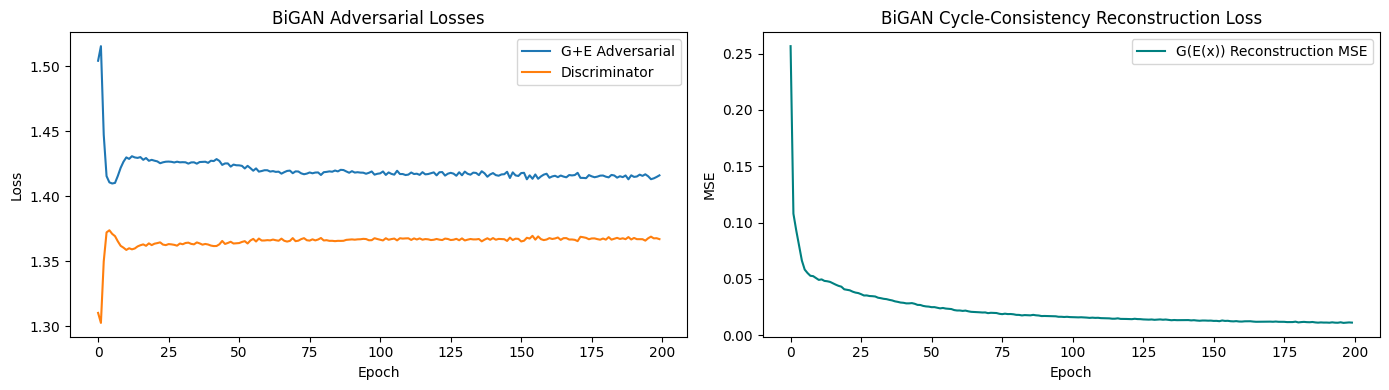

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(bi_ge_adv_losses, label='G+E Adversarial')
axes[0].plot(bi_d_losses,      label='Discriminator')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('BiGAN Adversarial Losses'); axes[0].legend()

axes[1].plot(bi_recon_losses, label='G(E(x)) Reconstruction MSE', color='teal')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MSE')
axes[1].set_title('BiGAN Cycle-Consistency Reconstruction Loss'); axes[1].legend()

plt.tight_layout(); plt.show()


### 4.3 Anomaly Scoring

For each test sample **x**:
1. Encode: `z = E(x)`
2. Reconstruct: `x_rec = G(E(x))`
3. Score = α · ||x − x_rec||₂ + β · ||f_D(x,z) − f_D(x_rec,z)||₂

This is a **single forward pass** — much faster than AnoGAN's z-optimisation.


In [40]:
@torch.no_grad()
def bigan_anomaly_score(G, E, D, x, alpha=0.5, beta=0.5):
    """
    Compute BiGAN anomaly scores in a single forward pass.

    Parameters
    ----------
    alpha : weight for reconstruction loss
    beta  : weight for discriminator feature-matching loss

    Returns
    -------
    scores : np.ndarray, shape (N,)
    """
    G.eval(); E.eval(); D.eval()
    z_enc  = E(x)
    x_rec  = G(z_enc)

    recon_loss = torch.mean((x - x_rec) ** 2, dim=1)
    feat_loss  = torch.mean(
        (D.get_features(x, z_enc) - D.get_features(x_rec, z_enc)) ** 2, dim=1
    )
    return (alpha * recon_loss + beta * feat_loss).cpu().numpy()


def normalize_scores(scores: np.ndarray, percentile: float = 99.5) -> np.ndarray:
    """
    Clip at the given percentile then min-max normalise to [0, 1].
    Rank-preserving (does not change ROC-AUC).
    """
    clip_val = np.percentile(scores, percentile)
    clipped  = np.clip(scores, 0, clip_val)
    lo, hi   = clipped.min(), clipped.max()
    return (clipped - lo) / (hi - lo + 1e-10)


# ── Score all evaluation samples ──────────────────────────────────────────────
print("Computing BiGAN anomaly scores (single forward pass)...")
bigan_scores_raw = bigan_anomaly_score(bi_G, bi_E, bi_D, eval_tensor)
print(f"Done. Raw score range: [{bigan_scores_raw.min():.4f}, {bigan_scores_raw.max():.4f}]")

# Normalise all scores to [0, 1] for fair comparison and ensembling
anogan_scores    = normalize_scores(anogan_scores_raw)
bigan_scores     = normalize_scores(bigan_scores_raw)

# Ensemble: simple average of normalised scores.
# Partially uncorrelated errors should average to a stronger combined signal.
ensemble_scores  = (anogan_scores + bigan_scores) / 2

print(f"\nNormalised AnoGAN  : [{anogan_scores.min():.4f}, {anogan_scores.max():.4f}]")
print(f"Normalised BiGAN   : [{bigan_scores.min():.4f},  {bigan_scores.max():.4f}]")
print(f"Ensemble (mean)    : [{ensemble_scores.min():.4f}, {ensemble_scores.max():.4f}]")


Computing BiGAN anomaly scores (single forward pass)...
Done. Raw score range: [0.0030, 80.5060]

Normalised AnoGAN  : [0.0000, 1.0000]
Normalised BiGAN   : [0.0000,  1.0000]
Ensemble (mean)    : [0.0022, 1.0000]


## 5. Evaluation & Comparison

### 5.1 Anomaly Score Distributions

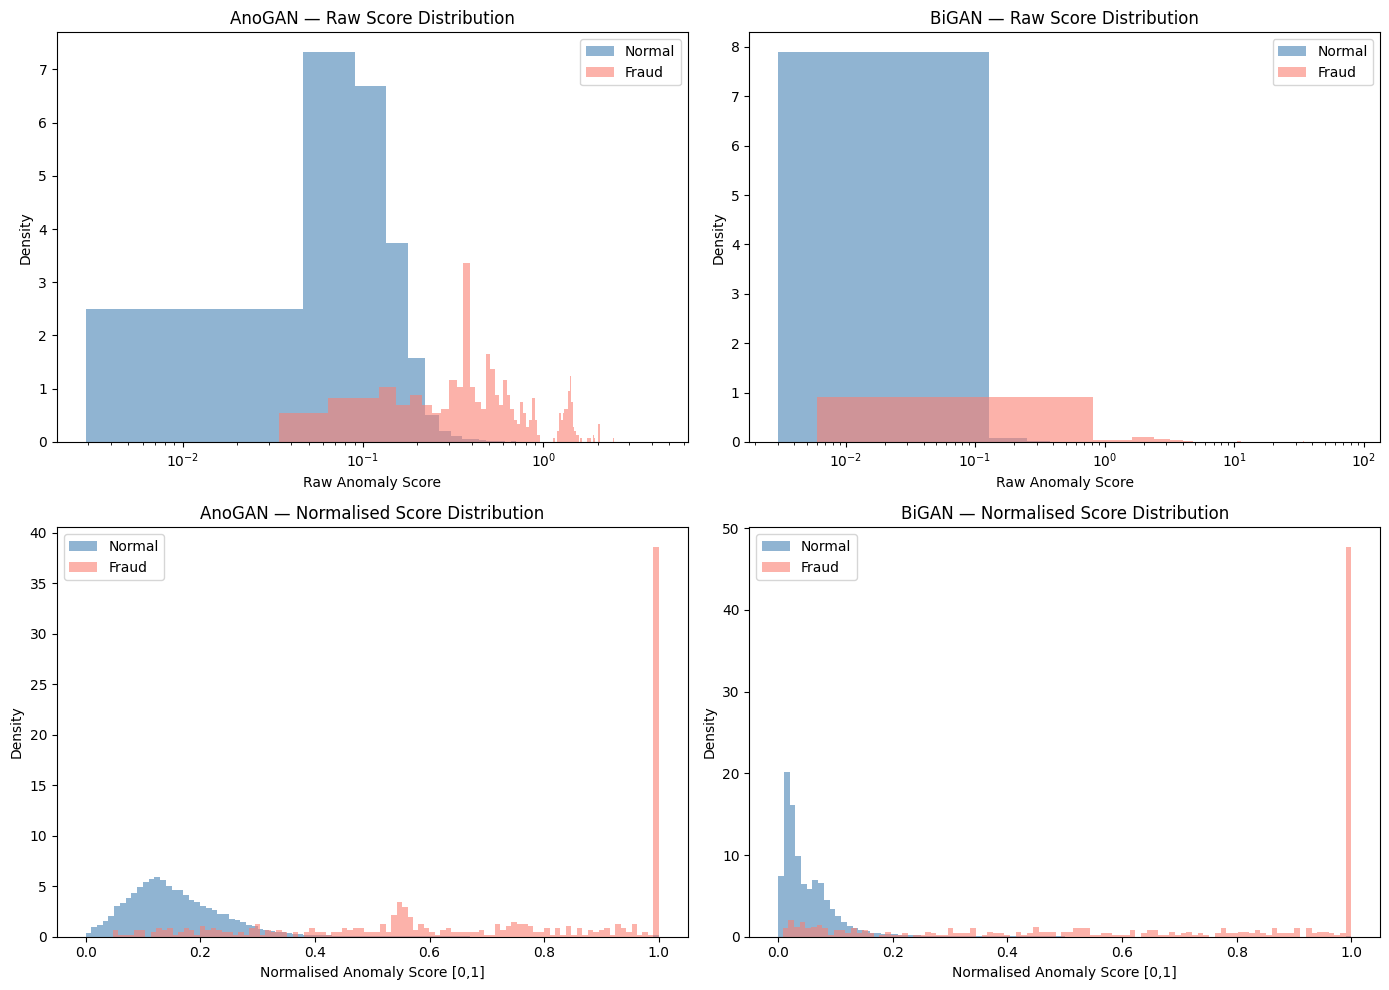

In [41]:
def plot_score_distributions(raw_scores_list, norm_scores_list, titles):
    """
    2-row grid: row 0 = raw scores (log x-scale), row 1 = normalised scores.
    Columns correspond to models supplied in the lists.
    """
    n = len(titles)
    fig, axes = plt.subplots(2, n, figsize=(7 * n, 10))

    for col, (raw_scores, norm_scores, title) in enumerate(
        zip(raw_scores_list, norm_scores_list, titles)
    ):
        for row, (scores, xlabel, log_scale) in enumerate([
            (raw_scores,  'Raw Anomaly Score',              True),
            (norm_scores, 'Normalised Anomaly Score [0,1]', False),
        ]):
            ax = axes[row][col]
            ax.hist(scores[y_eval == 0], bins=100, alpha=0.6,
                    label='Normal', density=True, color='steelblue')
            ax.hist(scores[y_eval == 1], bins=100, alpha=0.6,
                    label='Fraud',  density=True, color='salmon')
            ax.set_xlabel(xlabel); ax.set_ylabel('Density')
            label = 'Raw' if row == 0 else 'Normalised'
            ax.set_title(f'{title} — {label} Score Distribution')
            if log_scale:
                ax.set_xscale('log')
            ax.legend()

    plt.tight_layout(); plt.show()


plot_score_distributions(
    raw_scores_list  = [anogan_scores_raw, bigan_scores_raw],
    norm_scores_list = [anogan_scores,     bigan_scores],
    titles           = ['AnoGAN', 'BiGAN'],
)


### 5.2 ROC and Precision-Recall Curves

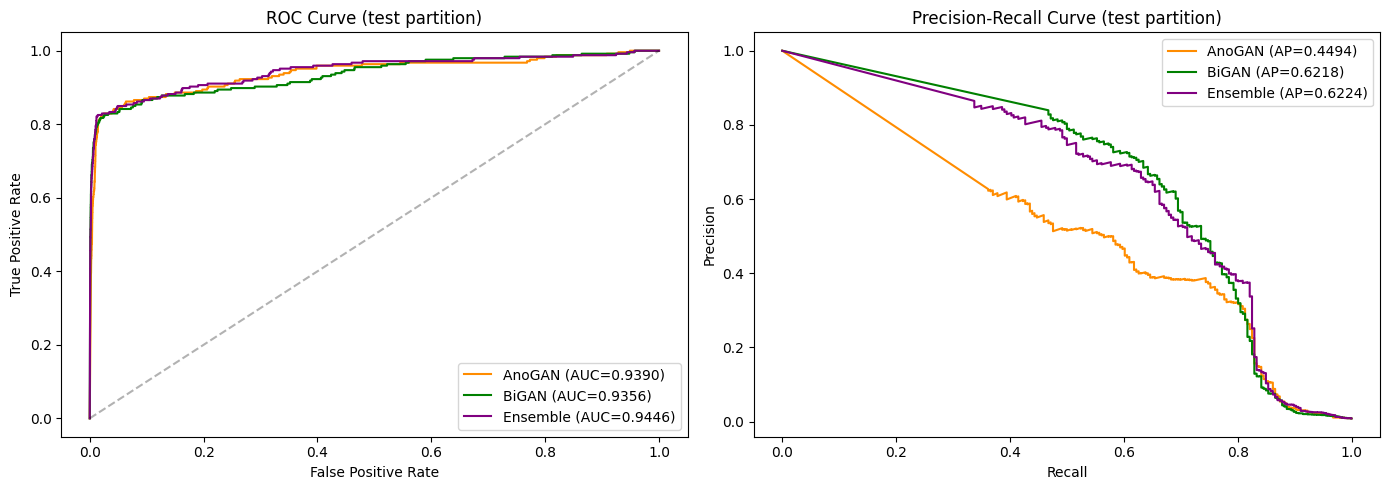

In [42]:
def plot_roc_pr(model_specs, y_true, test_idx, figsize=(14, 5)):
    """
    Plot ROC and Precision-Recall curves side-by-side.

    Parameters
    ----------
    model_specs : list of (scores, name, color)
    y_true      : ground-truth labels for the full evaluation set
    test_idx    : indices into the evaluation set for the test partition
    """
    fig, axes = plt.subplots(1, 2, figsize=figsize)

    for scores, name, color in model_specs:
        s_test = scores[test_idx]
        y_test = y_true[test_idx]

        fpr, tpr, _ = roc_curve(y_test, s_test)
        axes[0].plot(fpr, tpr, color=color,
                     label=f'{name} (AUC={roc_auc_score(y_test, s_test):.4f})')

        prec, rec, _ = precision_recall_curve(y_test, s_test)
        axes[1].plot(rec, prec, color=color,
                     label=f'{name} (AP={average_precision_score(y_test, s_test):.4f})')

    axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3)
    axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
    axes[0].set_title('ROC Curve (test partition)'); axes[0].legend()

    axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
    axes[1].set_title('Precision-Recall Curve (test partition)'); axes[1].legend()

    plt.tight_layout(); plt.show()


plot_roc_pr(
    model_specs = [
        (anogan_scores,    'AnoGAN',   'darkorange'),
        (bigan_scores,     'BiGAN',    'green'),
        (ensemble_scores,  'Ensemble', 'purple'),
    ],
    y_true   = y_eval,
    test_idx = test_idx,
)


### 5.3 Optimal Threshold, F1 Score, and Confusion Matrices


AnoGAN — Test Classification Report (val-tuned threshold = 0.7224):
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     28432
       Fraud       0.51      0.54      0.53       246

    accuracy                           0.99     28678
   macro avg       0.75      0.77      0.76     28678
weighted avg       0.99      0.99      0.99     28678


BiGAN — Test Classification Report (val-tuned threshold = 0.6431):
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     28432
       Fraud       0.70      0.63      0.66       246

    accuracy                           0.99     28678
   macro avg       0.85      0.81      0.83     28678
weighted avg       0.99      0.99      0.99     28678


Ensemble — Test Classification Report (val-tuned threshold = 0.7076):
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     28432
       Fraud       0.69      

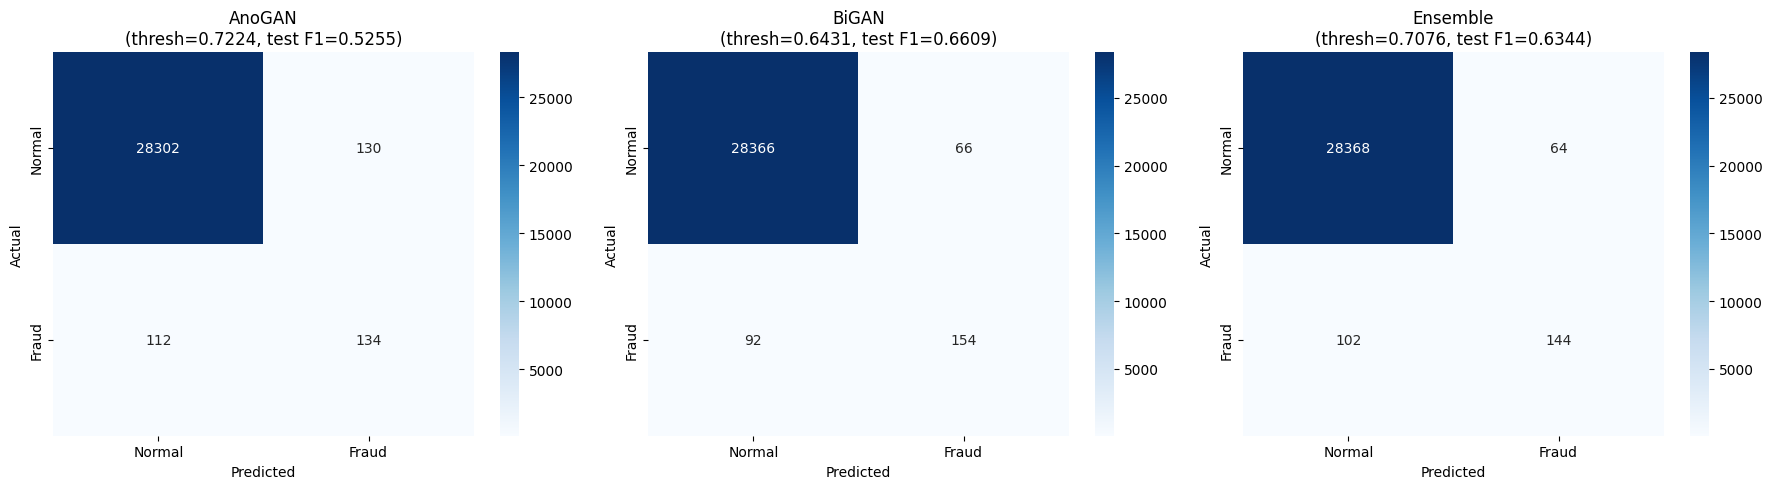

In [43]:
def find_best_f1_threshold(y_true: np.ndarray, scores: np.ndarray):
    """
    Select the threshold that maximises F1 on the given partition.

    Returns
    -------
    best_threshold : float
    best_f1        : float
    """
    precision, recall, thresholds = precision_recall_curve(y_true, scores)
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
    best_idx  = np.argmax(f1_scores)
    return thresholds[best_idx], f1_scores[best_idx]


def plot_confusion_matrices(model_specs, y_val, y_test, val_idx, test_idx):
    """
    Find the best threshold on val for each model, then plot the confusion matrix
    evaluated on the test partition.
    """
    n = len(model_specs)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))

    for ax, (scores, name, _) in zip(axes, model_specs):
        thresh, _ = find_best_f1_threshold(y_val, scores[val_idx])
        preds     = (scores[test_idx] >= thresh).astype(int)
        test_f1   = f1_score(y_test, preds)

        sns.heatmap(
            confusion_matrix(y_test, preds),
            annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Normal', 'Fraud'],
            yticklabels=['Normal', 'Fraud'],
        )
        ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
        ax.set_title(f'{name}\n(thresh={thresh:.4f}, test F1={test_f1:.4f})')

        print(f"\n{name} — Test Classification Report (val-tuned threshold = {thresh:.4f}):")
        print(classification_report(y_test, preds, target_names=['Normal', 'Fraud']))

    plt.tight_layout(); plt.show()


model_specs_base = [
    (anogan_scores,   'AnoGAN',   'darkorange'),
    (bigan_scores,    'BiGAN',    'green'),
    (ensemble_scores, 'Ensemble', 'purple'),
]

plot_confusion_matrices(model_specs_base, y_val, y_test, val_idx, test_idx)


### 5.4 t-SNE Visualisation of BiGAN Latent Space

Running t-SNE on 5,492 samples (492 fraud)...


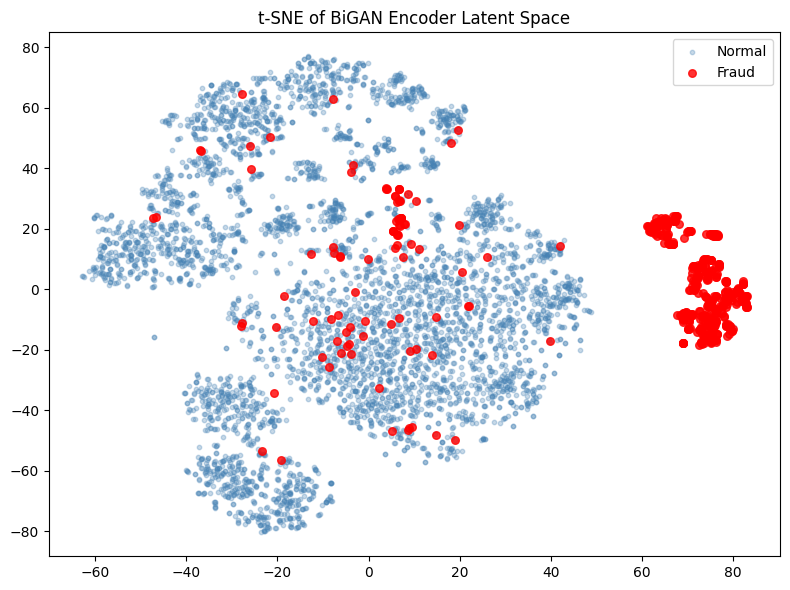

In [44]:
def plot_tsne_latent_space(encoder, eval_tensor, y_eval,
                            n_normal=5000, seed=SEED):
    """
    Encode all evaluation samples, sub-sample up to `n_normal` normal points,
    and visualise the latent space with t-SNE (all fraud points are kept).
    """
    encoder.eval()
    with torch.no_grad():
        z_all = encoder(eval_tensor).cpu().numpy()

    idx_normal = np.where(y_eval == 0)[0]
    idx_fraud  = np.where(y_eval == 1)[0]
    sample_normal = np.random.choice(
        idx_normal, min(n_normal, len(idx_normal)), replace=False
    )
    sample_idx = np.concatenate([sample_normal, idx_fraud])
    np.random.shuffle(sample_idx)

    z_sample = z_all[sample_idx]
    y_sample = y_eval[sample_idx]

    print(f"Running t-SNE on {len(z_sample):,} samples ({int(y_sample.sum())} fraud)...")
    z_2d = TSNE(n_components=2, random_state=seed, perplexity=30).fit_transform(z_sample)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(z_2d[y_sample == 0, 0], z_2d[y_sample == 0, 1],
               c='steelblue', alpha=0.3, s=10, label='Normal')
    ax.scatter(z_2d[y_sample == 1, 0], z_2d[y_sample == 1, 1],
               c='red', alpha=0.8, s=30, label='Fraud')
    ax.set_title('t-SNE of BiGAN Encoder Latent Space')
    ax.legend(); plt.tight_layout(); plt.show()


plot_tsne_latent_space(bi_E, eval_tensor, y_eval)


### 5.5 Summary Comparison Table

In [45]:
def compute_metrics(scores, y_val, y_test, val_idx, test_idx):
    """
    Compute a standard set of fraud-detection metrics.
    Threshold is selected on val; all reported metrics are on test.

    Returns a dict of metric_name → value.
    """
    s_val, s_test = scores[val_idx], scores[test_idx]
    roc_auc = roc_auc_score(y_test, s_test)
    pr_auc  = average_precision_score(y_test, s_test)

    thresh, _ = find_best_f1_threshold(y_val, s_val)
    preds     = (s_test >= thresh).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    precision = tp / (tp + fp + 1e-10)
    recall    = tp / (tp + fn + 1e-10)
    f1        = 2 * precision * recall / (precision + recall + 1e-10)
    accuracy  = (tp + tn) / (tp + tn + fp + fn)

    return {
        'Accuracy': accuracy, 'Precision': precision,
        'Recall': recall,     'F1-score': f1,
        'ROC-AUC': roc_auc,   'PR-AUC': pr_auc,
        'Threshold (val)': thresh,
        'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
    }


METRIC_COLS = ['Accuracy', 'Precision', 'Recall', 'F1-score',
               'ROC-AUC', 'PR-AUC', 'TP', 'FP', 'FN', 'TN', 'Threshold (val)']

results = {
    name: compute_metrics(scores, y_val, y_test, val_idx, test_idx)
    for scores, name, _ in model_specs_base
}

comparison_df = pd.DataFrame(results).T[METRIC_COLS]
print("=" * 90)
print("    AnoGAN vs BiGAN vs Ensemble — Fraud Detection (val-tuned threshold, test metrics)")
print("=" * 90)
comparison_df


    AnoGAN vs BiGAN vs Ensemble — Fraud Detection (val-tuned threshold, test metrics)


,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC,TP,FP,FN,TN,Threshold (val)
AnoGAN,0.991561,0.507576,0.544715,0.525490,0.938993,0.449396,134.0,130.0,112.0,28302.0,0.722398
BiGAN,0.994491,0.700000,0.626016,0.660944,0.935632,0.621776,154.0,66.0,92.0,28366.0,0.643102
Ensemble,0.994212,0.692308,0.585366,0.634361,0.944585,0.622411,144.0,64.0,102.0,28368.0,0.707588


## 6. Hyperparameter Sweeps & Ablations

Two analyses to validate design choices and extract additional performance:

1. **Ablation** — retrain BiGAN with `LAMBDA_RECON = 0` (no cycle-consistency).  
   Confirms whether the reconstruction term is genuinely beneficial.
2. **Sweeps on the validation partition** — select BiGAN's `α` (recon vs feature-matching weight)  
   and the ensemble mixing weight `w` by best val F1, then evaluate on test.  
   No test-set leakage.


### 6.1 BiGAN Ablation: With vs Without Reconstruction Term

Retrain an identical BiGAN architecture and schedule with `LAMBDA_RECON = 0`  
(pure adversarial, no cycle-consistency).  
If the recon term is genuinely useful, this model should score lower on val / test.


In [46]:
# Instantiate fresh BiGAN models for the ablation (no weight sharing with main BiGAN)
bi_G_nr = BiGAN_Generator(LATENT_DIM, INPUT_DIM).to(device)
bi_E_nr = BiGAN_Encoder(INPUT_DIM, LATENT_DIM).to(device)
bi_D_nr = BiGAN_Discriminator(INPUT_DIM, LATENT_DIM).to(device)

print("Training BiGAN ablation (LAMBDA_RECON = 0, otherwise identical)...")
_, _, _ = train_bigan(
    bi_G_nr, bi_E_nr, bi_D_nr, train_loader, NUM_EPOCHS_BI,
    lambda_recon=0.0,
)

print("\nScoring ablation BiGAN...")
bigan_nr_scores_raw = bigan_anomaly_score(bi_G_nr, bi_E_nr, bi_D_nr, eval_tensor)
bigan_nr_scores     = normalize_scores(bigan_nr_scores_raw)
print(f"BiGAN no-recon raw range: [{bigan_nr_scores_raw.min():.4f}, {bigan_nr_scores_raw.max():.4f}]")

# Quick ROC-AUC comparison
auc_with_recon    = roc_auc_score(y_test, bigan_scores[test_idx])
auc_without_recon = roc_auc_score(y_test, bigan_nr_scores[test_idx])
print(f"\nROC-AUC on test partition:")
print(f"  BiGAN with    recon (LAMBDA_RECON=1.0): {auc_with_recon:.4f}")
print(f"  BiGAN without recon (LAMBDA_RECON=0.0): {auc_without_recon:.4f}")
print(f"  Recon term contribution               : {auc_with_recon - auc_without_recon:+.4f}")


Training BiGAN ablation (LAMBDA_RECON = 0, otherwise identical)...
Epoch [25/200]  D: 1.3763  GE_adv: 1.3964  Recon: 2.2948
Epoch [50/200]  D: 1.3763  GE_adv: 1.3964  Recon: 1.9968
Epoch [75/200]  D: 1.3739  GE_adv: 1.4015  Recon: 1.7778
Epoch [100/200]  D: 1.3702  GE_adv: 1.4075  Recon: 1.7900
Epoch [125/200]  D: 1.3653  GE_adv: 1.4149  Recon: 1.8031
Epoch [150/200]  D: 1.3625  GE_adv: 1.4207  Recon: 1.9294
Epoch [175/200]  D: 1.3618  GE_adv: 1.4223  Recon: 1.7866
Epoch [200/200]  D: 1.3547  GE_adv: 1.4324  Recon: 1.7975

Scoring ablation BiGAN...
BiGAN no-recon raw range: [0.0434, 4025.8645]

ROC-AUC on test partition:
  BiGAN with    recon (LAMBDA_RECON=1.0): 0.9356
  BiGAN without recon (LAMBDA_RECON=0.0): 0.9350
  Recon term contribution               : +0.0007


### 6.2 BiGAN α Sweep + Optimal Ensemble Weight

**BiGAN α sweep:**  
Mix pure-reconstruction and pure-feature-matching scores as  
`score = α · recon + (1−α) · feat`, normalise, then sweep `α ∈ [0.0, 1.0]` on val.

**Ensemble weight sweep:**  
Sweep `w ∈ [0.0, 1.0]` for `score = w · AnoGAN + (1−w) · BiGAN_best` on val.

Both sweeps use **only the validation partition** for selection;  
final metrics are reported on the held-out test partition.


In [47]:
# Pre-compute pure component scores (single forward pass each)
print("Computing pure-recon and pure-feature BiGAN scores...")
bigan_recon_only = bigan_anomaly_score(bi_G, bi_E, bi_D, eval_tensor, alpha=1.0, beta=0.0)
bigan_feat_only  = bigan_anomaly_score(bi_G, bi_E, bi_D, eval_tensor, alpha=0.0, beta=1.0)

# ── α sweep ───────────────────────────────────────────────────────────────────
alpha_grid = np.round(np.arange(0.0, 1.01, 0.1), 2)
alpha_records = []
best_alpha, best_alpha_f1 = 0.5, -1.0

for a in alpha_grid:
    raw    = a * bigan_recon_only + (1 - a) * bigan_feat_only
    s      = normalize_scores(raw)
    thresh, f1_v = find_best_f1_threshold(y_val, s[val_idx])
    auc_v  = roc_auc_score(y_val, s[val_idx])
    alpha_records.append({'alpha': a, 'val_F1': f1_v, 'val_ROC-AUC': auc_v, 'val_thresh': thresh})
    if f1_v > best_alpha_f1:
        best_alpha_f1 = f1_v
        best_alpha    = a

alpha_sweep_df = pd.DataFrame(alpha_records)
print("\nBiGAN α sweep (val F1):")
print(alpha_sweep_df.to_string(index=False))
print(f"\n  Selected α* = {best_alpha}  (val F1 = {best_alpha_f1:.4f})")

bigan_best_scores = normalize_scores(
    best_alpha * bigan_recon_only + (1 - best_alpha) * bigan_feat_only
)

# ── Ensemble weight sweep ─────────────────────────────────────────────────────
w_grid = np.round(np.arange(0.0, 1.01, 0.05), 2)
w_records = []
best_w, best_w_f1 = 0.5, -1.0

for w in w_grid:
    s     = w * anogan_scores + (1 - w) * bigan_best_scores
    thresh, f1_v = find_best_f1_threshold(y_val, s[val_idx])
    auc_v = roc_auc_score(y_val, s[val_idx])
    w_records.append({'w (AnoGAN share)': w, 'val_F1': f1_v, 'val_ROC-AUC': auc_v})
    if f1_v > best_w_f1:
        best_w_f1 = f1_v
        best_w    = w

w_sweep_df = pd.DataFrame(w_records)
print("\nEnsemble weight sweep (val F1):")
print(w_sweep_df.to_string(index=False))
print(f"\n  Selected w* = {best_w}  (val F1 = {best_w_f1:.4f})")

ensemble_opt_scores = best_w * anogan_scores + (1 - best_w) * bigan_best_scores


Computing pure-recon and pure-feature BiGAN scores...

BiGAN α sweep (val F1):
 alpha   val_F1  val_ROC-AUC  val_thresh
   0.0 0.564103     0.923253    0.885770
   0.1 0.690678     0.949791    0.642697
   0.2 0.693617     0.950721    0.643917
   0.3 0.690832     0.951045    0.644023
   0.4 0.690832     0.951205    0.643419
   0.5 0.690832     0.951308    0.643102
   0.6 0.690832     0.951378    0.642891
   0.7 0.690832     0.951423    0.642739
   0.8 0.690832     0.951458    0.642625
   0.9 0.690832     0.951487    0.642537
   1.0 0.690832     0.951506    0.642466

  Selected α* = 0.2  (val F1 = 0.6936)

Ensemble weight sweep (val F1):
 w (AnoGAN share)   val_F1  val_ROC-AUC
             0.00 0.693617     0.950721
             0.05 0.690832     0.951654
             0.10 0.689507     0.952091
             0.15 0.690678     0.952250
             0.20 0.689076     0.952322
             0.25 0.687764     0.952164
             0.30 0.690678     0.951908
             0.35 0.689076     0.951

In [48]:
# Extended comparison across all variants
extended_model_specs = [
    (anogan_scores,       'AnoGAN'),
    (bigan_nr_scores,     'BiGAN (no recon — ablation)'),
    (bigan_scores,        'BiGAN (recon, α=0.5 default)'),
    (bigan_best_scores,   f'BiGAN (recon, α*={best_alpha})'),
    (ensemble_scores,     'Ensemble (mean, default)'),
    (ensemble_opt_scores, f'Ensemble (w*={best_w})'),
]

extended_results = {
    name: compute_metrics(scores, y_val, y_test, val_idx, test_idx)
    for scores, name in extended_model_specs
}

ext_df = pd.DataFrame(extended_results).T[METRIC_COLS]
print("\n" + "=" * 100)
print("    Extended Comparison: ablation + sweeps + ensembles  (val-tuned threshold, test metrics)")
print("=" * 100)
ext_df



    Extended Comparison: ablation + sweeps + ensembles  (val-tuned threshold, test metrics)


,Accuracy,Precision,Recall,F1-score,ROC-AUC,PR-AUC,TP,FP,FN,TN,Threshold (val)
AnoGAN,0.991561,0.507576,0.544715,0.525490,0.938993,0.449396,134.0,130.0,112.0,28302.0,0.722398
BiGAN (no recon — ablation),0.981066,0.218216,0.467480,0.297542,0.934965,0.239666,115.0,412.0,131.0,28020.0,0.269973
"BiGAN (recon, α=0.5 default)",0.994491,0.700000,0.626016,0.660944,0.935632,0.621776,154.0,66.0,92.0,28366.0,0.643102
"BiGAN (recon, α*=0.2)",0.994491,0.700000,0.626016,0.660944,0.935250,0.618366,154.0,66.0,92.0,28366.0,0.643917
"Ensemble (mean, default)",0.994212,0.692308,0.585366,0.634361,0.944585,0.622411,144.0,64.0,102.0,28368.0,0.707588
Ensemble (w*=0.0),0.994491,0.700000,0.626016,0.660944,0.935250,0.618366,154.0,66.0,92.0,28366.0,0.643917


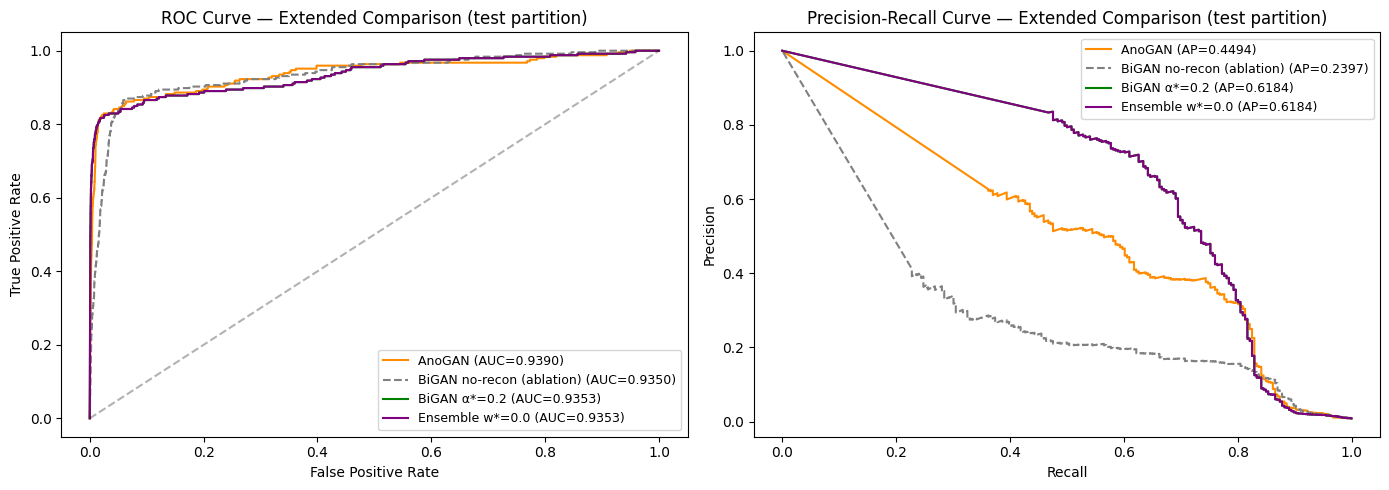

In [49]:
# Extended ROC and PR plots
ext_plot_specs = [
    (anogan_scores,       'AnoGAN',                      'darkorange', '-'),
    (bigan_nr_scores,     'BiGAN no-recon (ablation)',   'gray',       '--'),
    (bigan_best_scores,   f'BiGAN α*={best_alpha}',       'green',      '-'),
    (ensemble_opt_scores, f'Ensemble w*={best_w}',         'purple',     '-'),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for scores, name, color, ls in ext_plot_specs:
    s_test = scores[test_idx]

    fpr, tpr, _ = roc_curve(y_test, s_test)
    axes[0].plot(fpr, tpr, color=color, linestyle=ls,
                 label=f'{name} (AUC={roc_auc_score(y_test, s_test):.4f})')

    prec, rec, _ = precision_recall_curve(y_test, s_test)
    axes[1].plot(rec, prec, color=color, linestyle=ls,
                 label=f'{name} (AP={average_precision_score(y_test, s_test):.4f})')

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — Extended Comparison (test partition)')
axes[0].legend(fontsize=9)

axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve — Extended Comparison (test partition)')
axes[1].legend(fontsize=9)

plt.tight_layout(); plt.show()
